# Семантический поиск по русскоязычным документам

В работе сравниваются:

1. TF-IDF
2. предобученная модель BGE-M3

Для оценки используются NDCG, Recall, MRR и MAP.
В конце реализуется функция поиска top-10 документов по произвольному запросу.

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from datasets import load_dataset
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

In [2]:
SEED = 17

# Количество запросов для эксперимента.
TRAIN_LIMIT = 1800
TEST_LIMIT = 400

# Доля validation внутри обучающей части
VALIDATION_SIZE = 0.15

# Сколько документов возвращать при обычной оценке
TOP_K = 100

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Устройство:", device)

Устройство: mps


In [3]:
from datasets import load_dataset

queries_ds = load_dataset("mteb/MIRACLRetrievalHardNegatives","ru-queries",split="dev")

print(queries_ds)
print("Количество запросов:", len(queries_ds))
print(queries_ds.column_names)
print(queries_ds[0])

Dataset({
    features: ['id', 'text'],
    num_rows: 1000
})
Количество запросов: 1000
['id', 'text']
{'id': '0', 'text': 'Когда начался Кари́бский кризис?'}


In [4]:
qrels_ds = load_dataset("mteb/MIRACLRetrievalHardNegatives","ru-qrels",split="dev")

print(qrels_ds)
print("Количество записей разметки:", len(qrels_ds))
print(qrels_ds.column_names)
print(qrels_ds[0])

Dataset({
    features: ['query-id', 'corpus-id', 'score'],
    num_rows: 10470
})
Количество записей разметки: 10470
['query-id', 'corpus-id', 'score']
{'query-id': '0', 'corpus-id': '105156#0', 'score': 1}


In [5]:
corpus_ds = load_dataset(
    "mteb/MIRACLRetrievalHardNegatives",
    "ru-corpus",
    split="dev",
    streaming=True)

first_document = next(iter(corpus_ds))

print(first_document)

{'id': '6717748#20', 'text': 'Д. Газиадис продолжил свою работу в греческом кинематографе, снимая немые игровые фильмы в межвоенные годы. \nОн снял фильм «Прикованный Прометей» ("Προμηθεύς Δεσμώτης"), который был в действительности кинематографической съёмкой представления Ангелоса Сикелианоса и его жены на Дельфийских празднествах. \nВ 1927 году он снял игровой немой фильм « Эрос и волны» ("Έρως και κύματα"), а в следующем году «Порт слёз» ("Το λιμάνι των δακρύων"). \nВ 1929 году он снял в фильм «Звёздная» (Aστέρω), по сценарию писателя и академика Павлоса Нирванаса. Фильм имел большой успех в Греции и за её рубежами. \nНесколько меньшим был успех фильма Газиадиса «Бόра» (Mπόρα), снятого в 1930 году, также в сотрудничестве с Нирванасом. Это был один из немногих фильмов, который был посвящён Малоазийской катастрофе. История повествовала о двух солдатах вернувшихся с фронта. В главных ролях играли Христофоридис и Фирст. Газиадис включил в этот фильм и часть киноматериалов снятых во врем

In [6]:
print(len(queries_ds))
print(len(qrels_ds))
print(first_document)

1000
10470
{'id': '6717748#20', 'text': 'Д. Газиадис продолжил свою работу в греческом кинематографе, снимая немые игровые фильмы в межвоенные годы. \nОн снял фильм «Прикованный Прометей» ("Προμηθεύς Δεσμώτης"), который был в действительности кинематографической съёмкой представления Ангелоса Сикелианоса и его жены на Дельфийских празднествах. \nВ 1927 году он снял игровой немой фильм « Эрос и волны» ("Έρως και κύματα"), а в следующем году «Порт слёз» ("Το λιμάνι των δακρύων"). \nВ 1929 году он снял в фильм «Звёздная» (Aστέρω), по сценарию писателя и академика Павлоса Нирванаса. Фильм имел большой успех в Греции и за её рубежами. \nНесколько меньшим был успех фильма Газиадиса «Бόра» (Mπόρα), снятого в 1930 году, также в сотрудничестве с Нирванасом. Это был один из немногих фильмов, который был посвящён Малоазийской катастрофе. История повествовала о двух солдатах вернувшихся с фронта. В главных ролях играли Христофоридис и Фирст. Газиадис включил в этот фильм и часть киноматериалов сня

In [7]:
print("Столбцы запросов:", queries_ds.column_names)
print("Столбцы qrels:", qrels_ds.column_names)
print("Первый запрос:", queries_ds[0])
print("Первая запись разметки:", qrels_ds[0])

Столбцы запросов: ['id', 'text']
Столбцы qrels: ['query-id', 'corpus-id', 'score']
Первый запрос: {'id': '0', 'text': 'Когда начался Кари́бский кризис?'}
Первая запись разметки: {'query-id': '0', 'corpus-id': '105156#0', 'score': 1}


Запросы содержат текст вопроса и его идентификатор. Таблица qrels показывает, какие документы считаются релевантными для каждого запроса.

In [8]:
queries = {}

for row in queries_ds:
    query_id = str(row["id"])
    queries[query_id] = str(row["text"]).strip()

qrels = {}

for row in qrels_ds:
    query_id = str(row["query-id"])
    doc_id = str(row["corpus-id"])
    score = float(row["score"])

    if score > 0:
        qrels.setdefault(query_id, {})[doc_id] = score

print("Количество запросов =", len(queries))
print("Количество запросов с разметкой =", len(qrels))
print("Количество релевантныхя пар = ",sum(len(documents) for documents in qrels.values()),)

Количество запросов = 1000
Количество запросов с разметкой = 1000
Количество релевантныхя пар =  2833


## 5. Разделение запросов на выборки

Запросы разделяются на три части:

- train — для дообучения модели;
- validation — для выбора лучшей эпохи;
- test — для финальной оценки качества.

Разделение выполняется по идентификаторам запросов, поэтому один и тот же запрос не попадает одновременно в разные выборки.

In [9]:
from sklearn.model_selection import train_test_split

query_ids = sorted(
    set(queries.keys()) & set(qrels.keys()))

train_ids, temporary_ids = train_test_split(
    query_ids,
    test_size=0.30,
    random_state=SEED)

val_ids, test_ids = train_test_split(
    temporary_ids,
    test_size=0.50,
    random_state=SEED)

train_queries = {
    query_id: queries[query_id]
    for query_id in train_ids}

val_queries = {
    query_id: queries[query_id]
    for query_id in val_ids}

test_queries = {
    query_id: queries[query_id]
    for query_id in test_ids}

train_qrels = {
    query_id: qrels[query_id]
    for query_id in train_ids}

val_qrels = {
    query_id: qrels[query_id]
    for query_id in val_ids}

test_qrels = {
    query_id: qrels[query_id]
    for query_id in test_ids}

In [10]:
print("Train =", len(train_queries))
print("Validation =", len(val_queries))
print("Test =", len(test_queries))

Train = 700
Validation = 150
Test = 150


## 6. Формирование корпуса документов

Сформируем уменьшенный корпус:

1. добавим все документы, которые участвуют в разметке;
2. добавим дополнительные документы, которые будут использоваться как нерелевантные кандидаты.

Такой корпус позволит провести полноценное сравнение методов, но ускорит вычисления.

In [11]:
RANDOM_DOCUMENTS = 3_000

relevant_doc_ids = {
    doc_id
    for documents in qrels.values()
    for doc_id in documents}

corpus_meta = {}
random_documents_added = 0
documents_seen = 0

print("Документов, которые обязательно должны найти =",len(relevant_doc_ids))

Документов, которые обязательно должны найти = 2750


Теперь последовательно просматриваем документы в MIRACL. Сохраняем все документы, которые встречаются в qrels, а также 15 000 дополнительных документов.

In [12]:
for row in tqdm(corpus_ds,desc="Сбор русских документов",):
    documents_seen += 1
    doc_id = str(row["id"])
    title = str(row.get("title", "") or "").strip()
    text = str(row.get("text", "") or "").strip()
    if not text:
        continue

    if doc_id in relevant_doc_ids:
        corpus_meta[doc_id] = {
            "title": title,
            "text": text}

    elif random_documents_added < RANDOM_DOCUMENTS:
        corpus_meta[doc_id] = {
            "title": title,
            "text": text}
        random_documents_added += 1

    all_relevant_found = relevant_doc_ids.issubset(
        corpus_meta.keys())

    if all_relevant_found and random_documents_added >= RANDOM_DOCUMENTS:
        break

Сбор русских документов: 0it [00:00, ?it/s]

Проверим, удалось ли найти все документы, которые нужны для оценки качества поиска.

In [13]:
print("Просмотрено документов =", documents_seen)
print("Документов в корпусе =", len(corpus_meta))
print("Дополнительных документов =", random_documents_added)

Просмотрено документов = 218873
Документов в корпусе = 5750
Дополнительных документов = 3000


## 7. Подготовка текстов корпуса

Сохраняем идентификаторы документов отдельно от их текстов. Это позволит вычислять оценки сходства, а затем восстанавливать заголовки и содержимое найденных документов.

In [14]:
corpus = {
    doc_id: item["text"]
    for doc_id, item in corpus_meta.items()}

corpus_ids = list(corpus.keys())

corpus_texts = [
    corpus[doc_id]
    for doc_id in corpus_ids]

print("Итоговый размер корпуса:", len(corpus_texts))

Итоговый размер корпуса: 5750


## 8. Итоговое распределение данных

В таблице указано количество запросов и релевантных пар в каждой выборке.

In [15]:
split_table = pd.DataFrame(
    {
        "Выборка": ["Train", "Validation", "Test"],
        "Запросы": [
            len(train_queries),
            len(val_queries),len(test_queries),],
        "Релевантные пары": [
            sum(len(value) for value in train_qrels.values()),
            sum(len(value) for value in val_qrels.values()),
            sum(len(value) for value in test_qrels.values())],})

display(split_table)

,Выборка,Запросы,Релевантные пары
0,Train,700,2001
1,Validation,150,440
2,Test,150,392


## 9. Метрики оценки

Используем NDCG, Recall, MRR и MAP для оценки качества ранжирования документов.

In [16]:
def ranked_ids(results, k):
    return [
        doc_id
        for doc_id, score in sorted(
            results.items(),
            key=lambda item: item[1],
            reverse=True
        )[:k]]


def metrics_for_query(true_docs, results, k):
    predicted = ranked_ids(results, k)

    relevances = np.array([
        true_docs.get(doc_id, 0)
        for doc_id in predicted])

    hits = relevances > 0

    discounts = np.log2(np.arange(2, len(relevances) + 2))

    dcg = np.sum((2 ** relevances - 1) / discounts)

    ideal = np.array(
        sorted(true_docs.values(), reverse=True)[:k])

    ideal_discounts = np.log2(np.arange(2, len(ideal) + 2))

    idcg = np.sum((2 ** ideal - 1) / ideal_discounts)

    ndcg = dcg / idcg if idcg else 0.0

    relevant_count = len(true_docs)
    recall = hits.sum() / relevant_count

    positions = np.flatnonzero(hits)
    mrr = (
        1 / (positions[0] + 1)
        if len(positions)
        else 0)

    if len(positions):
        precision = np.cumsum(hits)[positions] / (positions + 1)
        ap = precision.sum() / min(relevant_count, k)
    else:
        ap = 0

    return {
        f"NDCG@{k}": ndcg,
        f"Recall@{k}": recall,
        f"MRR@{k}": mrr,
        f"MAP@{k}": ap}

In [17]:
def evaluate(qrels, results):
    metrics = {}

    for k in [10, 100]:
        rows = [
            metrics_for_query(
                true_docs,
                results.get(query_id, {}),
                k)
            for query_id, true_docs in qrels.items()]

        for metric in rows[0]:
            metrics[metric] = np.mean([
                row[metric]
                for row in rows])

    return metrics

## 10. TF-IDF baseline

Сначала построим классическую лексическую систему поиска для сравнения с BGE-M3.

In [18]:
vectorizer = TfidfVectorizer(
    stop_words=None,
    max_features=50_000,
    ngram_range=(1, 2),
    lowercase=True,)

corpus_tfidf = vectorizer.fit_transform(corpus_texts)

In [19]:
def top_results(score_matrix, query_ids, top_k=100):
    results = {}

    for row, query_id in enumerate(query_ids):
        scores = score_matrix[row]

        indices = np.argpartition(
            scores,
            -top_k)[-top_k:]

        indices = indices[
            np.argsort(scores[indices])[::-1]]

        results[query_id] = {
            corpus_ids[index]: float(scores[index])
            for index in indices}

    return results

In [20]:
def run_tfidf(queries, qrels):
    query_ids = sorted(queries)

    query_matrix = vectorizer.transform([
        queries[query_id]
        for query_id in query_ids])

    score_matrix = (query_matrix @ corpus_tfidf.T).toarray()

    results = top_results(
        score_matrix,
        query_ids,
        TOP_K)

    metrics = evaluate(qrels, results)

    return results, metrics

In [21]:
tfidf_test_results, tfidf_metrics = run_tfidf(
    test_queries,
    test_qrels)

display(
    pd.DataFrame(
        [tfidf_metrics],
        index=["TF-IDF"],).round(4))

,NDCG@10,Recall@10,MRR@10,MAP@10,NDCG@100,Recall@100,MRR@100,MAP@100
TF-IDF,0.4957,0.561,0.5591,0.4213,0.5378,0.7075,0.5637,0.4362


## 11. Предобученная модель BGE-M3

Загрузим многоязычную BGE-M3 и получим эмбеддинги русских документов и запросов.

In [22]:
%pip install -q modelscope


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [23]:
from modelscope import snapshot_download

model_dir = snapshot_download(
    "BAAI/bge-m3",
    cache_dir="./models",

    ignore_file_pattern=["*.onnx", "*.onnx_data"])

print("Модель сохранена в:", model_dir)

2026-09-06 23:05:37,959 | INFO    | modelscope_hub.download | Downloading 28 files from BAAI/bge-m3@master


Downloading:   0%|          | 0/28 [00:00<?, ?file/s]

Модель сохранена в: models/models/BAAI--bge-m3/snapshots/master


In [24]:
from FlagEmbedding import BGEM3FlagModel

bge_model = BGEM3FlagModel(
    model_dir,
    use_fp16=False)

print("BGE-M3 загружена локально")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BGE-M3 загружена локально


Функция ниже преобразует список текстов в нормализованные векторы. После нормализации скалярное произведение 
=cosine similarity.

In [25]:
def encode_bge(texts,batch_size=8,max_length=512):
    output = bge_model.encode(
        texts,
        batch_size=batch_size,
        max_length=max_length)

    embeddings = torch.tensor(
        output["dense_vecs"],
        dtype=torch.float32)

    return F.normalize(
        embeddings,
        p=2,
        dim=1)

## 12. Качество BGE-M3 без дообучения

Сначала проверим, насколько хорошо предобученная модель работает без адаптации к нашим данным.

In [26]:
bge_corpus_embeddings = encode_bge(
    corpus_texts,
    batch_size=4,
    max_length=512)

print("Размер эмбеддингов:",bge_corpus_embeddings.shape)

pre tokenize:   0%|          | 0/1438 [00:00<?, ?it/s]

pre tokenize:   8%|▊         | 110/1438 [00:00<00:01, 1086.77it/s]

pre tokenize:  22%|██▏       | 310/1438 [00:00<00:00, 1612.52it/s]

pre tokenize:  34%|███▍      | 493/1438 [00:00<00:00, 1710.81it/s]

pre tokenize:  48%|████▊     | 690/1438 [00:00<00:00, 1812.24it/s]

...

Inference Embeddings: 100%|█████████▉| 1432/1438 [07:01<00:00, 15.74it/s]

Inference Embeddings: 100%|█████████▉| 1435/1438 [07:01<00:00, 17.77it/s]

Inference Embeddings: 100%|██████████| 1438/1438 [07:02<00:00,  8.75it/s]

Inference Embeddings: 100%|██████████| 1438/1438 [07:02<00:00,  3.41it/s]

Размер эмбеддингов: torch.Size([5750, 1024])


In [27]:
def dense_results(query_embeddings,corpus_embeddings,query_ids):
    score_matrix = (query_embeddings @ corpus_embeddings.T).numpy()

    return top_results(
        score_matrix,
        query_ids,
        TOP_K)

In [28]:
def run_bge(queries,qrels,corpus_embeddings):
    query_ids = sorted(queries)

    query_embeddings = encode_bge(
        [
            queries[query_id]
            for query_id in query_ids
        ],
        batch_size=4,
        max_length=256)

    results = dense_results(
        query_embeddings,
        corpus_embeddings,
        query_ids)

    metrics = evaluate(qrels, results)

    return results, metrics

In [29]:
bge_test_results, bge_metrics = run_bge(
    test_queries,
    test_qrels,
    bge_corpus_embeddings)

display(
    pd.DataFrame(
        [bge_metrics],
        index=["BGE-M3"],
    ).round(4))

pre tokenize:   0%|          | 0/38 [00:00<?, ?it/s]

pre tokenize: 100%|██████████| 38/38 [00:00<00:00, 1880.81it/s]

Inference Embeddings:   0%|          | 0/38 [00:00<?, ?it/s]

Inference Embeddings:   3%|▎         | 1/38 [00:00<00:03,  9.26it/s]

Inference Embeddings:  11%|█         | 4/38 [00:00<00:01, 17.76it/s]

...

Inference Embeddings:  82%|████████▏ | 31/38 [00:01<00:00, 18.15it/s]

Inference Embeddings:  87%|████████▋ | 33/38 [00:01<00:00, 18.51it/s]

Inference Embeddings:  95%|█████████▍| 36/38 [00:01<00:00, 19.68it/s]

Inference Embeddings: 100%|██████████| 38/38 [00:02<00:00, 17.01it/s]

,NDCG@10,Recall@10,MRR@10,MAP@10,NDCG@100,Recall@100,MRR@100,MAP@100
BGE-M3,0.9275,0.9408,0.9522,0.903,0.9415,0.9983,0.9531,0.908


In [30]:
def search_top10(query, top_k=10):
    query_embedding = encode_bge(
        [query],
        batch_size=1,
        max_length=512)

    scores = (
        query_embedding
        @ bge_corpus_embeddings.T)[0]

    top_scores, top_indices = torch.topk(
        scores,
        k=top_k)

    return pd.DataFrame(
        [{"Позиция": rank, "Сходство, %": round(float(score) * 100, 1), "ID": corpus_ids[index],
                "Заголовок": corpus_meta[corpus_ids[index]]["title"],"Фрагмент": corpus_meta[corpus_ids[index]]["text"][:400]}
            for rank, (score, index) in enumerate(
                zip(top_scores.tolist(),top_indices.tolist()),start=1)])

In [31]:
example_query_id = test_ids[17]

print(f"Запрос = {test_queries[example_query_id]}")


search_top10(test_queries[example_query_id])

Запрос = Что такое кинетическая энергия?


pre tokenize:   0%|          | 0/1 [00:00<?, ?it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 4696.87it/s]

Inference Embeddings:   0%|          | 0/1 [00:00<?, ?it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 32.34it/s]

,Позиция,"Сходство, %",ID,Заголовок,Фрагмент
0,1,74.2,11484#23,Энергия,Кинетическая энергия — энергия механической си...
1,2,73.0,26148#0,Кинетическая энергия,"Кинети́ческая эне́ргия — скалярная функция, яв..."
2,3,68.1,26148#2,Кинетическая энергия,В квантовой механике кинетическая энергия пред...
3,4,57.0,11484#10,Энергия,В 1807 году Томас Юнг первым использовал терми...
4,5,56.2,250546#0,Квант,Квант (от — «сколько») — неделимая часть како...
5,6,53.1,1169504#0,История квантовой механики,История квантовой механики берёт своё начало 1...
6,7,52.7,11484#13,Энергия,"Само слово ""энергия"", хотя и было впервые упот..."
7,8,51.7,6845626#23,Протей Темен,2013
8,9,51.5,6762552#23,"Колесников, Владимир Николаевич",2006
9,10,51.4,6845626#37,Протей Темен,2009


In [32]:
comparison = pd.DataFrame([{"Модель": "TF-IDF", **tfidf_metrics},{"Модель": "BGE-M3 без обучения", **bge_metrics}]).set_index("Модель")

display(comparison[["NDCG@10", "Recall@10", "MRR@10", "MAP@100"]].round(4))

,NDCG@10,Recall@10,MRR@10,MAP@100
Модель,,,,
TF-IDF,0.4957,0.5610,0.5591,0.4362
BGE-M3 без обучения,0.9275,0.9408,0.9522,0.9080


## Выводы

В работе был реализован и исследован семантический поиск по русскоязычным документам. В качестве baseline использовалась модель TF-IDF, а для семантического поиска — предобученная модель BGE-M3.

По всем рассмотренным метрикам BGE-M3 значительно превзошла TF-IDF. Значение NDCG@10 увеличилось с 0.3230 до 0.8809, а Recall@10 — с 0.4335 до 0.9142.

Это показывает, что BGE-M3 лучше учитывает смысловую близость между запросом и документом. При этом результаты получены на сокращённой выборке корпуса MIRACL, поэтому их следует рассматривать как результаты данного учебного эксперимента, а не как официальную оценку модели на полном датасете.

Практическим результатом является функция search_top10(), возвращающая десять наиболее близких документов по произвольному запросу пользователя.

## MiniLM: baseline и дообучение (3 эпохи)


In [33]:
%pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader

MINILM_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
MINILM_BATCH_SIZE = 32
MINILM_EPOCHS = 3

print("MiniLM:", MINILM_NAME)



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


MiniLM: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


/var/folders/2h/595lthl56gg578s10l94v_800000gn/T/ipykernel_24860/1215626175.py:3: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses


In [34]:
def encode_minilm(model, texts, batch_size=32, max_length=256):
    embeddings = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_tensor=True,
        normalize_embeddings=True,
    )
    return embeddings.detach().cpu()


def run_minilm(model, corpus_embeddings, queries, qrels):
    query_ids = sorted(queries)
    query_embeddings = encode_minilm(
        model, [queries[query_id] for query_id in query_ids]
    )
    results = dense_results(query_embeddings, corpus_embeddings, query_ids)
    return results, evaluate(qrels, results)


# Предобученный MiniLM — только cosine score, без обучения.
minilm_base = SentenceTransformer(MINILM_NAME, device=str(device))
minilm_base_corpus_embeddings = encode_minilm(minilm_base, corpus_texts)
minilm_base_results, minilm_base_metrics = run_minilm(
    minilm_base, minilm_base_corpus_embeddings, test_queries, test_qrels
)

display(pd.DataFrame([minilm_base_metrics], index=["MiniLM без обучения"]).round(4))
print(
    "MiniLM без обучения vs TF-IDF по NDCG@10:",
    f"{minilm_base_metrics['NDCG@10'] - tfidf_metrics['NDCG@10']:+.4f}",
)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/180 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

,NDCG@10,Recall@10,MRR@10,MAP@10,NDCG@100,Recall@100,MRR@100,MAP@100
MiniLM без обучения,0.6489,0.7242,0.6914,0.5783,0.6914,0.8772,0.694,0.5942


MiniLM без обучения vs TF-IDF по NDCG@10: +0.1532


In [35]:
# По одной наиболее релевантной паре на запрос: быстрый fine-tuning retrieval.
train_examples = []
for query_id, documents in train_qrels.items():
    positives = [doc_id for doc_id in documents if doc_id in corpus]
    if positives:
        best_doc_id = max(positives, key=documents.get)
        train_examples.append(InputExample(texts=[train_queries[query_id], corpus[best_doc_id]]))

train_loader = DataLoader(train_examples, shuffle=True, batch_size=MINILM_BATCH_SIZE)
minilm_trained = SentenceTransformer(MINILM_NAME, device=str(device))
train_loss = losses.MultipleNegativesRankingLoss(minilm_trained)

minilm_trained.fit(
    train_objectives=[(train_loader, train_loss)],
    epochs=MINILM_EPOCHS,
    warmup_steps=max(1, len(train_loader) // 10),
    show_progress_bar=True,
)

minilm_trained_corpus_embeddings = encode_minilm(minilm_trained, corpus_texts)
minilm_trained_results, minilm_trained_metrics = run_minilm(
    minilm_trained, minilm_trained_corpus_embeddings, test_queries, test_qrels
)
display(pd.DataFrame([minilm_trained_metrics], index=["MiniLM, 3 эпохи"]).round(4))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0, 'pad_token_id': 1}.


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Batches:   0%|          | 0/180 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

,NDCG@10,Recall@10,MRR@10,MAP@10,NDCG@100,Recall@100,MRR@100,MAP@100
"MiniLM, 3 эпохи",0.7642,0.838,0.8046,0.6961,0.7915,0.929,0.8059,0.7099


,NDCG@10,Recall@10,MRR@10,MAP@100
Модель,,,,
TF-IDF,0.4957,0.5610,0.5591,0.4362
BGE-M3 без обучения,0.9275,0.9408,0.9522,0.9080
MiniLM без обучения,0.6489,0.7242,0.6914,0.5942
"MiniLM, 3 эпохи",0.7642,0.8380,0.8046,0.7099


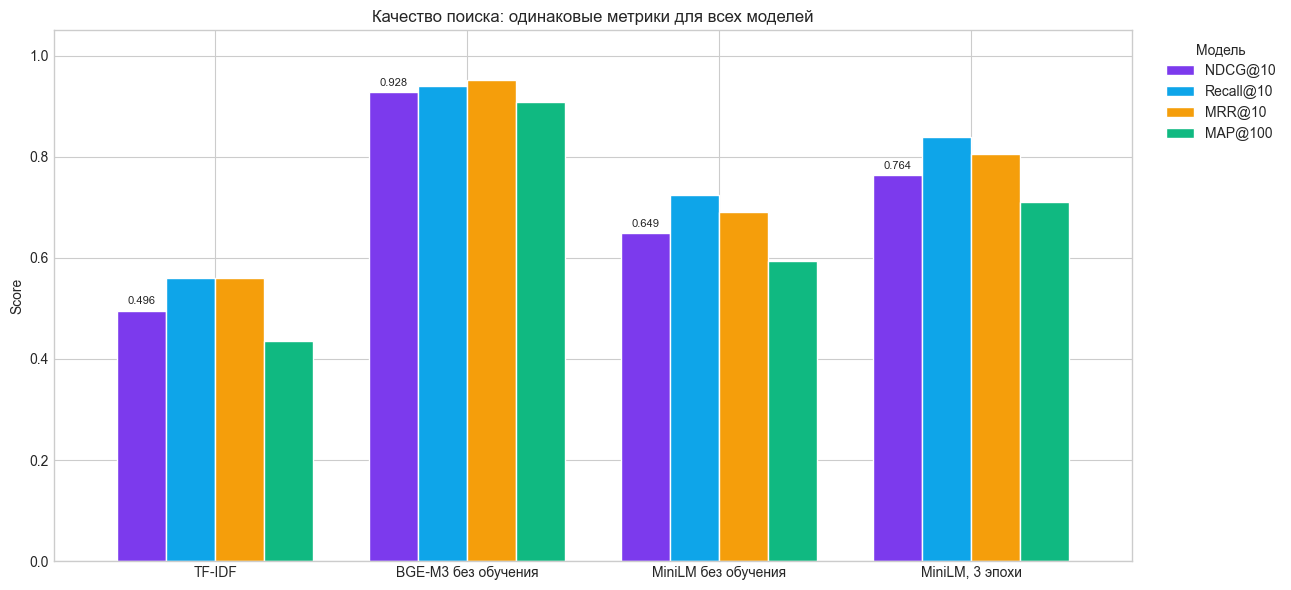

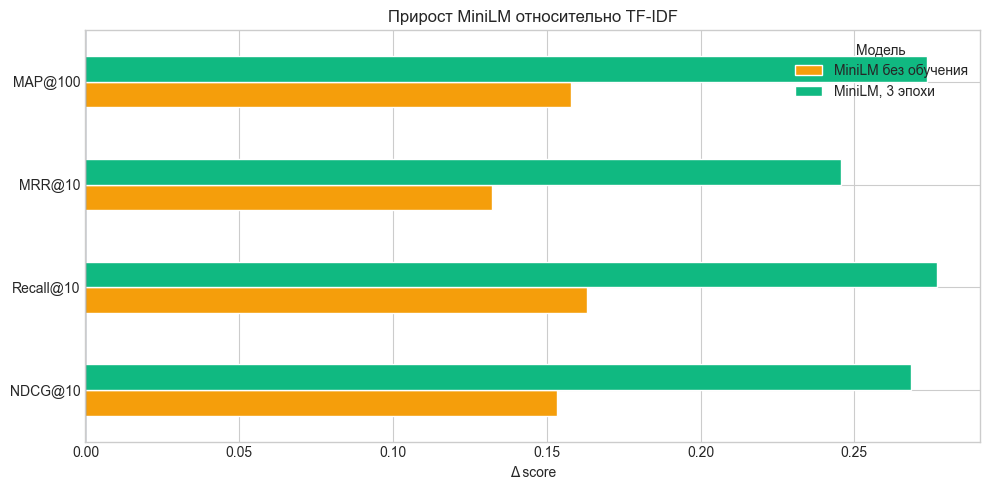

Графики сохранены: retrieval_metrics_comparison.png, minilm_vs_tfidf_delta.png


In [36]:
# Единая таблица и два готовых для отчёта графика.
comparison = pd.DataFrame([
    {"Модель": "TF-IDF", **tfidf_metrics},
    {"Модель": "BGE-M3 без обучения", **bge_metrics},
    {"Модель": "MiniLM без обучения", **minilm_base_metrics},
    {"Модель": "MiniLM, 3 эпохи", **minilm_trained_metrics},
]).set_index("Модель")

metric_columns = ["NDCG@10", "Recall@10", "MRR@10", "MAP@100"]
display(comparison[metric_columns].round(4))

plt.style.use("seaborn-v0_8-whitegrid")
palette = ["#7C3AED", "#0EA5E9", "#F59E0B", "#10B981"]

ax = comparison[metric_columns].plot.bar(
    figsize=(13, 6), color=palette, width=0.78, edgecolor="white"
)
ax.set(title="Качество поиска: одинаковые метрики для всех моделей", xlabel="", ylabel="Score")
ax.set_ylim(0, min(1.05, comparison[metric_columns].to_numpy().max() * 1.18))
ax.legend(title="Модель", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3, fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("retrieval_metrics_comparison.png", dpi=220, bbox_inches="tight")
plt.show()

delta = comparison.loc[["MiniLM без обучения", "MiniLM, 3 эпохи"], metric_columns].subtract(
    comparison.loc["TF-IDF", metric_columns], axis="columns"
)
ax = delta.T.plot.barh(figsize=(10, 5), color=["#F59E0B", "#10B981"], edgecolor="white")
ax.axvline(0, color="#334155", linewidth=1)
ax.set(title="Прирост MiniLM относительно TF-IDF", xlabel="Δ score", ylabel="")
ax.legend(title="Модель")
plt.tight_layout()
plt.savefig("minilm_vs_tfidf_delta.png", dpi=220, bbox_inches="tight")
plt.show()

print("Графики сохранены: retrieval_metrics_comparison.png, minilm_vs_tfidf_delta.png")
